In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 3 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 20

20

In [7]:
M = randn(d,d) * 0.5
J = M * M'

10×10 Matrix{Float64}:
  1.69297     0.338745   -0.0757963  …  -0.771465   -0.452183   1.08993
  0.338745    1.95871    -0.276452      -0.210706    0.802412   1.01286
 -0.0757963  -0.276452    0.439358      -0.0746725  -0.653363  -0.298017
 -1.15325     1.05394     0.443328       1.13078     0.545089  -0.836583
 -0.421239    0.0662798   0.138912       0.270875   -0.409614  -0.736237
  0.773889    0.407553   -0.0133459  …  -0.502692    0.209891   0.797144
  0.202425   -0.817597    0.39344        0.199477   -0.609672  -0.749984
 -0.771465   -0.210706   -0.0746725      1.47257     0.943829  -1.60048
 -0.452183    0.802412   -0.653363       0.943829    2.18317   -0.275785
  1.08993     1.01286    -0.298017      -1.60048    -0.275785   3.11977

In [8]:
eigen(inv(J))

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
10-element Vector{Float64}:
   0.1475365540389283
   0.2072790899133981
   0.28972679534904194
   0.38570903014608626
   0.7031163466989133
   0.9436531496997559
   1.2730636990535125
   2.3217839605429598
   9.540103660702131
 148.85502764693518
vectors:
10×10 Matrix{Float64}:
 -0.36297     0.0113933   0.166736   …  -0.409872    0.250408    0.0837385
 -0.0387103   0.554549   -0.0135012      0.555671   -0.308684   -0.142316
  0.0578803  -0.0982366   0.20206        0.17007     0.337531   -0.790591
  0.541398    0.459767    0.325106      -0.214604    0.171251    0.312379
  0.240853    0.0395474   0.365621      -0.177392    0.127882   -0.204481
 -0.201126    0.269321    0.566277   …   0.0943884  -0.153834    0.00148335
  0.0648094  -0.380563    0.451076       0.0996653  -0.0157422   0.0367394
  0.392837   -0.0174701  -0.139849      -0.463875   -0.603977   -0.373405
  0.158611    0.344435   -0.383806      -0.0647946   0.5306

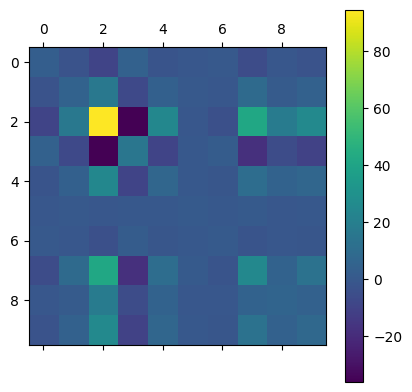

PyObject <matplotlib.colorbar.Colorbar object at 0x75dc51bcdf90>

In [9]:
matshow(inv(J))
colorbar()

In [10]:
θ0 = zeros(d)
θ1 = randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

4.723947569775562

In [11]:
γ = 0.1

0.1

In [12]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

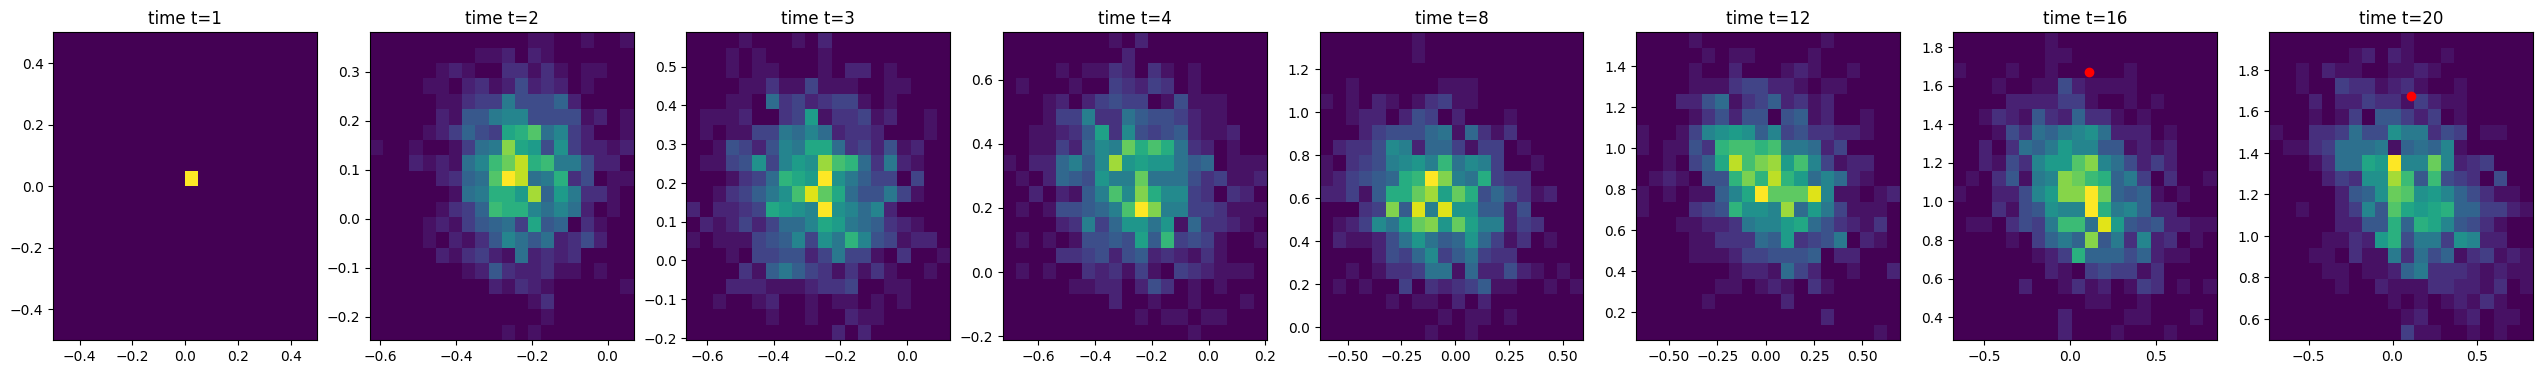

In [13]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

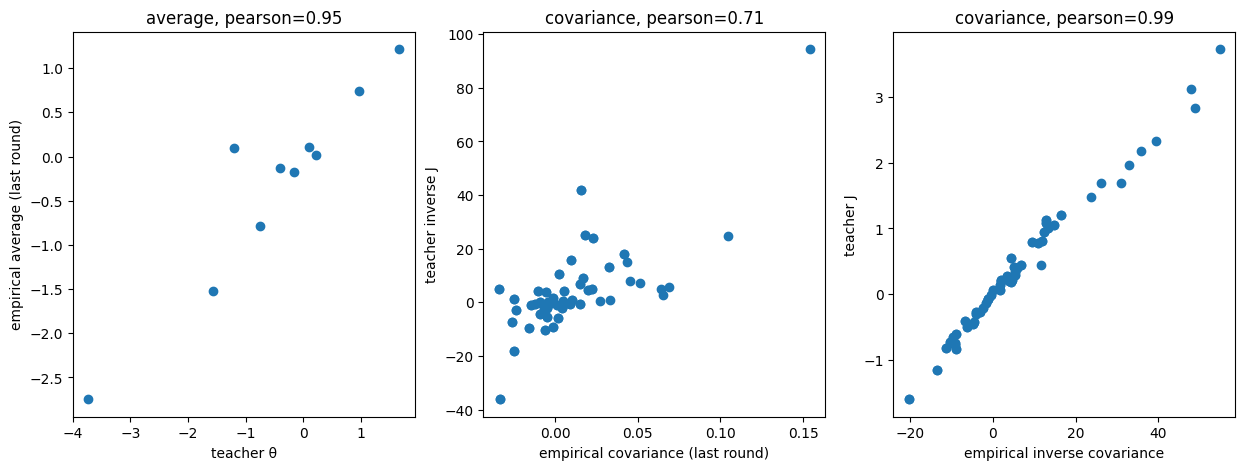

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [14]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [32]:
t_sample=[1, 2, 3, 4, 5, 15]

6-element Vector{Int64}:
  1
  2
  3
  4
  5
 15

In [33]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
deltas = [1,1,1,1,10]
data = collect_data(x[:,:,t_sample], counts, deltas);

In [34]:
l_values_gamma, x_opt_gamma, status_gamma = learn_gamma_nlopt(data, initialize=length(t_sample), λ=0.5, prior=0.0, ftol_rel=1e-7)

(-5.345471597299347, [29.460365393696843, 4.0363219489897695, 33.77032908794645, -1.3189835783637258, -3.5714797590584784, 12.785908836443829, -15.006201606165193, 15.723821356911305, 6.326540888488811, 57.24893010277932  …  1.969119145435217, 0.26594508940147343, -1.0556466337496642, -0.3482616061374878, 0.037440874536385386, -1.7252943008764805, -0.18975082886912356, 0.3709075204108642, -3.60020200455245, 0.005116922319891007], :FTOL_REACHED)

In [35]:
x_opt_gamma[end]

0.005116922319891007

In [36]:
J_inferred = de.compute_J(x_opt_gamma, data.d);
θ_inferred = de.compute_theta(x_opt_gamma, data.d);

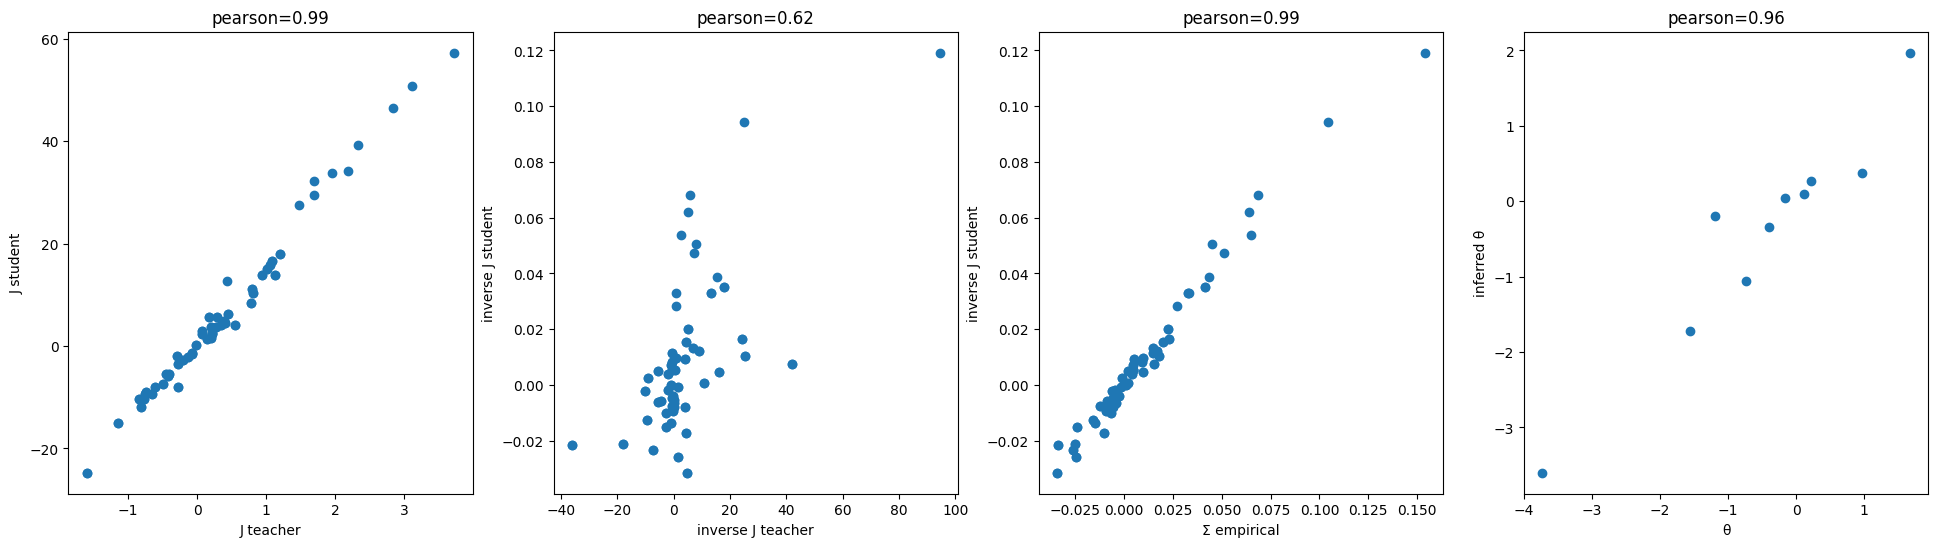

PyObject Text(0.5, 1.0, 'pearson=0.96')

In [37]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, θ_inferred)
rho_theta = cor(vec(θ), θ_inferred)
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [44]:
γ = collect(0.001:0.002:1.0)#vcat([0.001, 0.005], collect(0.1:0.1:1.5))

500-element Vector{Float64}:
 0.001
 0.003
 0.005
 0.007
 0.009
 0.011
 0.013
 0.015
 0.017
 0.019
 0.021
 0.023
 0.025
 ⋮
 0.977
 0.979
 0.981
 0.983
 0.985
 0.987
 0.989
 0.991
 0.993
 0.995
 0.997
 0.999

In [45]:
lγ = map(x->de.log_likelihood(x_opt_gamma[1:end-1], data, x, 0.0, 0.00), γ)

500-element Vector{Float64}:
  86.27987124088033
 -13.513520062862753
 -25.614852003115896
 -26.20140320861452
 -23.38747009522309
 -19.312647215377012
 -14.771849482674995
 -10.11845897915471
  -5.525194426106654
  -1.0793301135110056
   3.17641405893029
   7.224031894732678
  11.059667662840326
   ⋮
 124.92827361183966
 124.92838988728202
 124.92850401334574
 124.92861603167654
 124.92872598308377
 124.92883390755787
 124.92893984428731
 124.92904383167495
 124.92914590735406
 124.92924610820455
 124.929344470368
 124.92944102926326

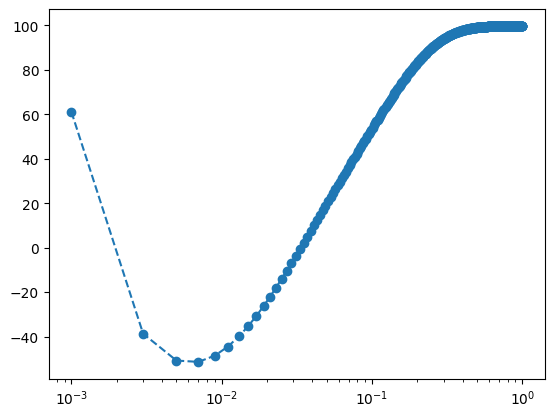

In [48]:
plot(γ, lγ .+ (minimum(lγ) + 1.0), linestyle="dashed", marker="o")
xscale(:log)

In [ ]:
x_opt_gamma

# using gamma from teacher

In [ ]:
de.npars(100)